In [2]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 85.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.0/91.0 kB 11.1 MB/s eta 0:00:00


In [39]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [42]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')

results = model.train(
    data='/content/drive/MyDrive/YOLOData/data.yaml',
    epochs=100,
    imgsz=640,
    project='/content/drive/MyDrive/YOLO_Projects',
    name='cookie_model'
)

Ultralytics 8.4.163 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/YOLOData/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=cookie_model-3, nbs=64, nms=None, 

In [43]:
from google.colab import files
files.download('/content/runs/detect/train/weights/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


image 1/1 /content/drive/MyDrive/test_images/Снимок экрана от 2026-09-26 10-57-52.png: 384x640 1 cookie, 5.7ms
Speed: 1.8ms preprocess, 5.7ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)


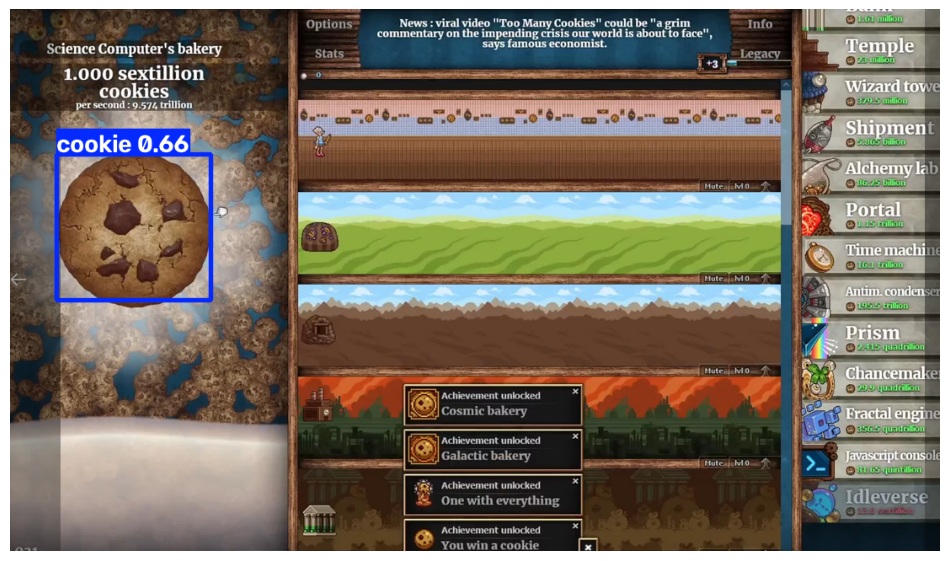

Класс: cookie, Уверенность: 0.66, Координаты: [55.51201629638672, 172.39920043945312, 238.2427520751953, 345.6514587402344]


In [50]:
from ultralytics import YOLO
import matplotlib.pyplot as plt

model = YOLO('/content/drive/MyDrive/YOLO_Projects/cookie_model-3/weights/best.pt')

img_path = '/content/drive/MyDrive/test_images/Снимок экрана от 2026-09-26 10-57-52.png'

results = model(img_path)

annotated = results[0].plot()
annotated = annotated[:, :, ::-1]

plt.figure(figsize=(12, 8))
plt.imshow(annotated)
plt.axis('off')
plt.show()

for box in results[0].boxes:
    print(f"Класс: {model.names[int(box.cls)]}, "
          f"Уверенность: {box.conf.item():.2f}, "
          f"Координаты: {box.xyxy[0].tolist()}")